# 05 - PC Member Source Breakdown Plot

This notebook creates the source breakdown plot using the cleaned PC service data.

The plot has three panels:

- Researchr/SIGPLAN PC page names
- Researchr/SIGPLAN external committee names (`EPC` or `ERC`)
- HotCRP confirmed committee names

The counts use the name mapped comparison table from notebook 04.


## 1 - Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.patches import Patch


In [2]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

from project_setup import setup_project

setup = setup_project()
project_folder = setup.project_folder
PROJECT = project_folder
repo = project_folder
config_path = setup.config_path
project_config = setup.project_config

run_mode = setup.run_mode
inputs_config = setup.inputs
outputs_config = setup.outputs
openalex_config = setup.openalex

allow_network = setup.allow_network
use_existing_data = setup.use_existing_data
overwrite_data = setup.overwrite_data
overwrite_artifacts = setup.overwrite_artifacts
openalex_sample_limit = setup.openalex_sample_limit
openalex_sample_include_work_ids = setup.openalex_sample_include_work_ids

step_1_data_dir = project_folder / "step_1_data"
step_1_artifacts_dir = project_folder / "step_1_artifacts"
prepared_dir = step_1_data_dir / "prepared"
intermediate_dir = step_1_data_dir / "intermediate"
summary_tables_dir = step_1_artifacts_dir / "summary_tables"
dependency_tables_dir = step_1_artifacts_dir / "dependency_tables"
check_tables_dir = step_1_artifacts_dir / "check_tables"
images_dir = step_1_artifacts_dir / "figures"

intermediate_dir.mkdir(parents=True, exist_ok=True)
prepared_dir.mkdir(parents=True, exist_ok=True)
summary_tables_dir.mkdir(parents=True, exist_ok=True)
dependency_tables_dir.mkdir(parents=True, exist_ok=True)
check_tables_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

print(project_folder)
print(f"Run mode: {run_mode}")


/Users/endersari/2026-02-citations-vs-pc-memberships
Run mode: fast


In [3]:
font_path = project_folder / "fonts" / "LinLibertine_R.ttf"
font_prop = font_manager.FontProperties(fname=font_path)

mpl.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": font_prop.get_name(),
    "text.usetex": True,
})

CONFERENCES = ["ICFP", "POPL", "OOPSLA", "PLDI"]
YEARS = list(range(2017, 2026))

COLORS = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "PLDI": "#e5c890",
}


## 2 - Load Data

In [4]:
comparison = pd.read_parquet(
    intermediate_dir / "hotcrp_researchr_name_comparison.parquet"
)
external_summary = pd.read_csv(dependency_tables_dir / "researchr_external_fetch_summary.csv")

print(comparison.shape)
display(comparison.head())


(3029, 22)


,conference,year,name_norm,name_hotcrp,name_canonical_hotcrp,affiliation_hotcrp,on_hotcrp,name_pc,name_canonical_pc,affiliation_pc,...,name_canonical_epc,affiliation_epc,on_epc,name_erc,name_canonical_erc,affiliation_erc,on_erc,name_canonical,on_researchr_any,category
0,ICFP,2017,adam chlipala,Adam Chlipala,Adam Chlipala,MIT CSAIL,True,Adam Chlipala,Adam Chlipala,"Massachusetts Institute of Technology, USA",...,NaN,NaN,False,NaN,NaN,NaN,False,Adam Chlipala,True,HotCRP and Researchr
1,ICFP,2017,alan jeffrey,Alan Jeffrey,Alan Jeffrey,Mozilla Research,True,Alan Jeffrey,Alan Jeffrey,Mozilla Research,...,NaN,NaN,False,NaN,NaN,NaN,False,Alan Jeffrey,True,HotCRP and Researchr
2,ICFP,2017,alexandra silva,Alexandra Silva,Alexandra Silva,University College London,True,Alexandra Silva,Alexandra Silva,University College London,...,NaN,NaN,False,NaN,NaN,NaN,False,Alexandra Silva,True,HotCRP and Researchr
3,ICFP,2017,ben lippmeier,Ben Lippmeier,Ben Lippmeier,Digital Asset,True,Ben Lippmeier,Ben Lippmeier,Digital Asset / UNSW Australia,...,NaN,NaN,False,NaN,NaN,NaN,False,Ben Lippmeier,True,HotCRP and Researchr
4,ICFP,2017,beta ziliani,Beta Ziliani,Beta Ziliani,"CONICET and FAMAF, Universidad Nacional de Cór...",True,Beta Ziliani,Beta Ziliani,"FAMAF, UNC and CONICET",...,NaN,NaN,False,NaN,NaN,NaN,False,Beta Ziliani,True,HotCRP and Researchr


## 3 - Build Count Tables

In [5]:
def count_table(mask):
    counts = (
        comparison.loc[mask]
        .groupby(["year", "conference"])["name_norm"]
        .nunique()
        .unstack("conference")
        .reindex(index=YEARS, columns=CONFERENCES)
        .astype(float)
    )
    return counts


hotcrp_counts = count_table(comparison["on_hotcrp"])
pc_counts = count_table(comparison["on_pc"])
external_counts = count_table(comparison["on_epc"] | comparison["on_erc"])

external_fetched = (
    external_summary
    .assign(is_fetched=lambda d: d["status"].isin(["fetched", "cache"]))
    .groupby(["conference", "year"])["is_fetched"]
    .any()
)

for conf in CONFERENCES:
    for year in YEARS:
        is_fetched = bool(external_fetched.get((conf, year), False))
        if not is_fetched:
            external_counts.loc[year, conf] = np.nan
        elif pd.isna(external_counts.loc[year, conf]):
            external_counts.loc[year, conf] = 0

print("HotCRP")
display(hotcrp_counts)
print("Researchr PC")
display(pc_counts)
print("Researchr EPC/ERC")
display(external_counts)


HotCRP


conference,ICFP,POPL,OOPSLA,PLDI
year,,,,
2017,23.0,89.0,59.0,106.0
2018,63.0,52.0,56.0,112.0
2019,72.0,52.0,66.0,111.0
2020,60.0,53.0,93.0,115.0
2021,30.0,53.0,107.0,126.0
2022,42.0,56.0,89.0,120.0
2023,55.0,84.0,143.0,113.0
2024,51.0,91.0,147.0,139.0
2025,63.0,82.0,113.0,137.0


Researchr PC


conference,ICFP,POPL,OOPSLA,PLDI
year,,,,
2017,23.0,29.0,31.0,36.0
2018,18.0,52.0,30.0,38.0
2019,20.0,52.0,32.0,39.0
2020,17.0,54.0,32.0,43.0
2021,30.0,52.0,51.0,126.0
2022,42.0,56.0,47.0,119.0
2023,54.0,84.0,78.0,113.0
2024,51.0,91.0,108.0,135.0
2025,63.0,82.0,115.0,137.0


Researchr EPC/ERC


conference,ICFP,POPL,OOPSLA,PLDI
year,,,,
2017,NaN,59.0,28.0,69.0
2018,43.0,NaN,26.0,72.0
2019,51.0,NaN,32.0,70.0
2020,42.0,NaN,61.0,72.0
2021,NaN,NaN,53.0,NaN
2022,NaN,NaN,40.0,NaN
2023,NaN,NaN,60.0,NaN
2024,NaN,NaN,NaN,NaN
2025,NaN,NaN,0.0,NaN


In [6]:
count_rows = []

for source, counts in [
    ("Researchr PC", pc_counts),
    ("Researchr EPC/ERC", external_counts),
    ("HotCRP", hotcrp_counts),
]:
    for year in YEARS:
        for conf in CONFERENCES:
            value = counts.loc[year, conf]
            count_rows.append({
                "source": source,
                "conference": conf,
                "year": year,
                "n_members": int(value) if pd.notna(value) else np.nan,
                "available": bool(pd.notna(value)),
            })

plot_counts = pd.DataFrame(count_rows)
plot_counts.to_csv(summary_tables_dir / "pc_members_bar_chart_breakdown_counts.csv", index=False)

display(plot_counts.head())


,source,conference,year,n_members,available
0,Researchr PC,ICFP,2017,23.0,True
1,Researchr PC,POPL,2017,29.0,True
2,Researchr PC,OOPSLA,2017,31.0,True
3,Researchr PC,PLDI,2017,36.0,True
4,Researchr PC,ICFP,2018,18.0,True


## 4 - Plot

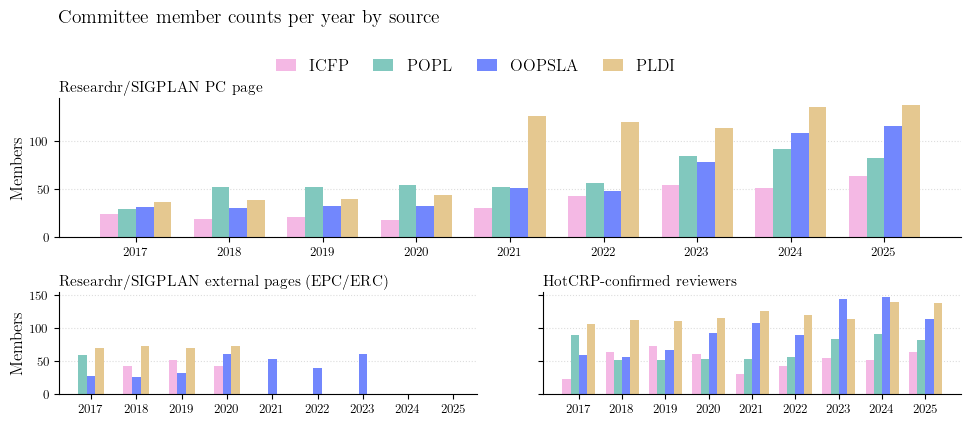

saved step_1_artifacts/figures/pc_members_bar_chart_breakdown.pdf
saved step_1_artifacts/figures/pc_members_bar_chart_breakdown.png


In [7]:
def render_year_conf_bars(counts, ax, title, *, show_legend=False, ylabel="Members"):
    x = np.arange(len(YEARS))
    width = 0.19
    labelled = set()

    for i, year in enumerate(YEARS):
        present = [conf for conf in CONFERENCES if pd.notna(counts.loc[year, conf])]
        for j, conf in enumerate(present):
            offset = (j - (len(present) - 1) / 2) * width
            ax.bar(
                x[i] + offset,
                counts.loc[year, conf],
                width,
                color=COLORS[conf],
                label=conf if conf not in labelled else None,
            )
            labelled.add(conf)

    ax.set_xticks(x)
    ax.set_xticklabels(YEARS, rotation=0)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(color="#DDDDDD", linestyle=":")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(title, fontsize=11, loc="left", pad=5)
    ax.tick_params(labelsize=9)


fig = plt.figure(figsize=(9.8, 4.35))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.35, 1],
    hspace=0.46,
    wspace=0.16,
    left=0.075,
    right=0.995,
    top=0.78,
    bottom=0.10,
)

ax_top = fig.add_subplot(gs[0, :])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1], sharey=ax_bl)

render_year_conf_bars(
    pc_counts,
    ax_top,
    "Researchr/SIGPLAN PC page",
    show_legend=True,
    ylabel="Members",
)
render_year_conf_bars(
    external_counts,
    ax_bl,
    "Researchr/SIGPLAN external pages (EPC/ERC)",
    ylabel="Members",
)
render_year_conf_bars(
    hotcrp_counts,
    ax_br,
    "HotCRP-confirmed reviewers",
    ylabel="",
)
ax_br.tick_params(labelleft=False)

handles = [Patch(facecolor=COLORS[conf], label=conf) for conf in CONFERENCES]
fig.legend(
    handles=handles,
    bbox_to_anchor=(0.5, 0.905),
    loc="upper center",
    ncol=len(CONFERENCES),
    frameon=False,
    columnspacing=1.5,
    handlelength=1.2,
)

fig.suptitle(
    "Committee member counts per year by source",
    fontsize=14,
    x=0.075,
    y=0.985,
    ha="left",
)

pdf_out = images_dir / "pc_members_bar_chart_breakdown.pdf"
png_out = images_dir / "pc_members_bar_chart_breakdown.png"

fig.savefig(pdf_out, bbox_inches="tight", pad_inches=0.03)
fig.savefig(png_out, bbox_inches="tight", pad_inches=0.03, dpi=220)
plt.show()

print("saved", pdf_out.relative_to(repo))
print("saved", png_out.relative_to(repo))


## 5 - What I Observe

In [8]:
summary = pd.read_csv(check_tables_dir / "hotcrp_researchr_overlap_summary.csv")

keep = [
    "conference", "year", "n_hotcrp", "n_pc", "n_epc", "n_erc",
    "n_researchr_any", "n_hotcrp_in_researchr_any",
    "share_hotcrp_in_researchr_any",
]

display(summary[keep].sort_values(["conference", "year"]))


,conference,year,n_hotcrp,n_pc,n_epc,n_erc,n_researchr_any,n_hotcrp_in_researchr_any,share_hotcrp_in_researchr_any
0,ICFP,2017,23,23,0,0,23,23,1.000
1,ICFP,2018,63,18,0,43,61,61,0.968
2,ICFP,2019,72,20,0,51,71,71,0.986
3,ICFP,2020,60,17,0,42,59,59,0.983
4,ICFP,2021,30,30,0,0,30,30,1.000
5,ICFP,2022,42,42,0,0,42,42,1.000
6,ICFP,2023,55,54,0,0,54,54,0.982
7,ICFP,2024,51,51,0,0,51,51,1.000
8,ICFP,2025,63,63,0,0,63,63,1.000
9,OOPSLA,2017,59,31,28,0,59,59,1.000


The visual pattern is the same as the source comparison table:

- in several early years, HotCRP is much larger than the visible PC page alone;
- PLDI changes after 2021, when the public PC/review committee page becomes the main large committee page.